In [24]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:

!unzip -q "/content/drive/MyDrive/Copy of dataset.zip" -d /content/

replace /content/dataset/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/__MACOSX/dataset/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/dataset/train/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/__MACOSX/dataset/train/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/dataset/val/.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/__MACOSX/dataset/val/._.DS_Store? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/dataset/train/vort/531.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: no
replace /content/dataset/train/vort/6912.npy? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [40]:
import torch
import numpy as np
import os
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [41]:

import os
if os.path.exists('/content/dataset/dataset/train'):
    BASE_DIR = '/content/dataset/dataset'

elif os.path.exists('/content/dataset/train'):
    BASE_DIR = '/content/dataset'

elif os.path.exists('/content/train'):
    BASE_DIR = '/content'

else:
    print("....")
    print(os.listdir('/content/'))

print(f"Using BASE_DIR: {BASE_DIR}")

def collect_files(split):
    paths, labels = [], []
    label_map = {'no': 0, 'sphere': 1, 'vort': 2}
    for cls_name, label in label_map.items():
        folder = os.path.join(BASE_DIR, split, cls_name)
        for f in os.listdir(folder):
            if f.endswith('.npy'):
                paths.append(os.path.join(folder, f))
                labels.append(label)
    return paths, labels

train_paths, train_labels = collect_files('train')
val_paths, val_labels = collect_files('val')

print(f"Train: {len(train_paths)}, Val: {len(val_paths)}")
print(f"Train dist: {Counter(train_labels)}")
print(f"Val dist: {Counter(val_labels)}")

Using BASE_DIR: /content/dataset
Train: 30000, Val: 7500
Train dist: Counter({0: 10000, 1: 10000, 2: 10000})
Val dist: Counter({0: 2500, 1: 2500, 2: 2500})


In [42]:
class LDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = np.load(self.paths[idx]).astype(np.float32)
        if img.ndim == 2:
            img = np.expand_dims(img, axis=0)
        img_tensor = torch.tensor(img)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        if self.transform:
            img_tensor = self.transform(img_tensor)
        return img_tensor, label

train_dataset = LDataset(train_paths, train_labels)
val_dataset = LDataset(val_paths, val_labels)

img, label = train_dataset[0]
print(f"Image shape: {img.shape}, Label: {label}")

Image shape: torch.Size([1, 150, 150]), Label: 0


In [43]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
])

train_dataset = LDataset(train_paths, train_labels, transform=train_transform)
val_dataset = LDataset(val_paths, val_labels, transform=None)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Train batches: 469, Val batches: 118


In [44]:
model = models.resnet18(weights='IMAGENET1K_V1')
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
model.fc = nn.Linear(512, 3)
model = model.to(device)

In [45]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5)

os.makedirs('/content/results', exist_ok=True)
epochs = 10
best_val_acc = 0

for epoch in range(epochs):
    model.train()
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    scheduler.step()
    train_acc = correct / total

    model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), '/content/results/best_model.pth')

    print(f"Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

print(f"\nBest Val Acc: {best_val_acc:.4f}")

Epoch 1/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 1: Train Acc=0.3633, Val Acc=0.4315


Epoch 2/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 2: Train Acc=0.4905, Val Acc=0.5859


Epoch 3/10:   0%|          | 0/469 [00:00<?, ?it/s]

...

Epoch 8: Train Acc=0.7646, Val Acc=0.8049


Epoch 9/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 9: Train Acc=0.7748, Val Acc=0.7883


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10: Train Acc=0.7864, Val Acc=0.8391

Best Val Acc: 0.8391


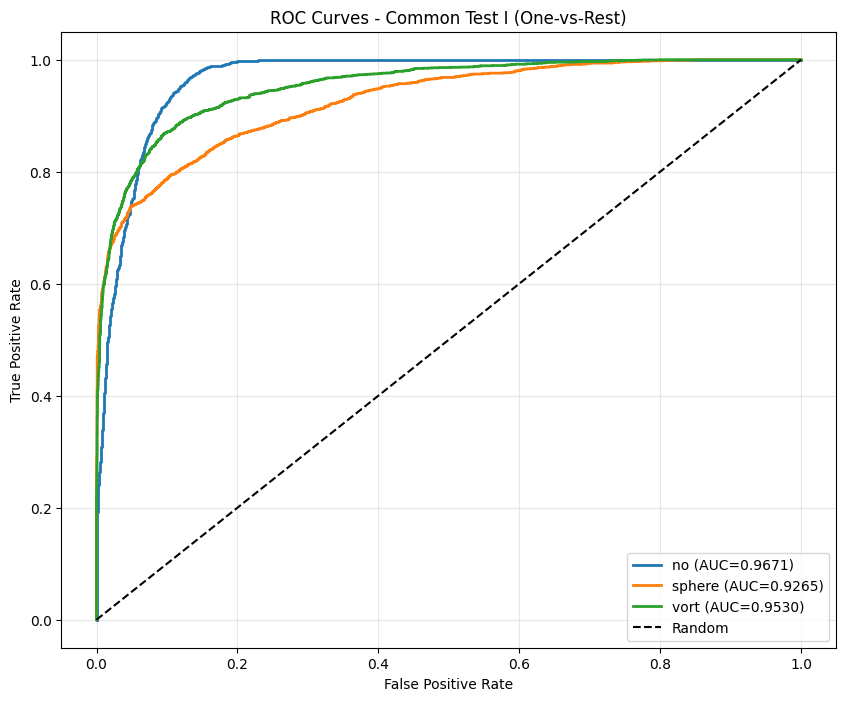

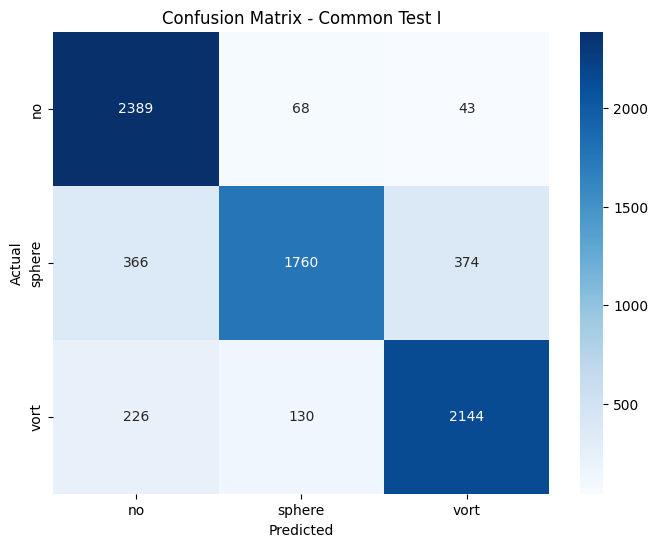

Per-class AUC: {'no': np.float64(0.9671), 'sphere': np.float64(0.9265), 'vort': np.float64(0.953)}
Macro AUC: 0.9489

Classification Report:
              precision    recall  f1-score   support

          no       0.80      0.96      0.87      2500
      sphere       0.90      0.70      0.79      2500
        vort       0.84      0.86      0.85      2500

    accuracy                           0.84      7500
   macro avg       0.85      0.84      0.84      7500
weighted avg       0.85      0.84      0.84      7500


Saved to /content/results/


In [48]:
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import json
model.load_state_dict(torch.load('/content/results/best_model.pth', map_location=device))


model.eval()

all_probs = []
all_preds = []
all_labels_eval = []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        _, predicted = outputs.max(1)
        all_probs.extend(probs)
        all_preds.extend(predicted.cpu().numpy())
        all_labels_eval.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_preds = np.array(all_preds)
all_labels_eval = np.array(all_labels_eval)
all_labels_bin = label_binarize(all_labels_eval, classes=[0, 1, 2])
class_names = ['no', 'sphere', 'vort']

# ROC curves
plt.figure(figsize=(10, 8))
aucs = []
for i, cls_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    auc = roc_auc_score(all_labels_bin[:, i], all_probs[:, i])
    aucs.append(auc)
    plt.plot(fpr, tpr, lw=2, label=f'{cls_name} (AUC={auc:.4f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Common Test I (One-vs-Rest)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.savefig('/content/results/roc_curve_task1.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = confusion_matrix(all_labels_eval, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Common Test I')
plt.savefig('/content/results/confusion_matrix_task1.png', dpi=300, bbox_inches='tight')
plt.show()

macro_auc = np.mean(aucs)
print(f"Per-class AUC: {dict(zip(class_names, [round(a,4) for a in aucs]))}")
print(f"Macro AUC: {macro_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(all_labels_eval, all_preds, target_names=class_names))

metrics = {
    "model": "ResNet18_pretrained_3class",
    "macro_auc": round(float(macro_auc), 4),
    "per_class_auc": dict(zip(class_names, [round(float(a), 4) for a in aucs])),
    "best_val_acc": round(float(best_val_acc), 4)
}
with open('/content/results/task1_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print("\nSaved to /content/results/")